# WCE Classification — Evaluation & Comparison
Load saved results from all three model notebooks and generate
full comparison plots, confusion matrices, and classification reports.

**Run AFTER:** `EfficientNetB0.ipynb`, `InceptionV3.ipynb`, `ResNet101V2.ipynb`

## Setup

In [7]:
import os, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (14, 6), 'font.size': 12,
                     'axes.titlesize': 14, 'axes.labelsize': 12})
print("Imports done.")


Imports done.


### Upload Result Files Manually

In [8]:
from google.colab import files
import io

print("Upload your 3 result files:")
print("  EfficientNetB0_results.pkl")
print("  InceptionV3_results.pkl")
print("  ResNet101V2_results.pkl")
print()
uploaded = files.upload()  # opens Colab's file picker
print(f"\nUploaded files: {list(uploaded.keys())}")


Upload your 3 result files:
  EfficientNetB0_results.pkl
  InceptionV3_results.pkl
  ResNet101V2_results.pkl



Saving ResNet101V2_results (1).pkl to ResNet101V2_results (1) (1).pkl
Saving InceptionV3_results (1).pkl to InceptionV3_results (1) (1).pkl
Saving EfficientNetB0_results (1).pkl to EfficientNetB0_results (1) (1).pkl

Uploaded files: ['ResNet101V2_results (1) (1).pkl', 'InceptionV3_results (1) (1).pkl', 'EfficientNetB0_results (1) (1).pkl']


### Load Results from All Three Models

In [15]:
all_results   = {}
CLASS_NAMES   = None
WARMUP_EPOCHS = None
WARMUP_LR     = None
FINETUNE_LR   = None

for model_name in ['EfficientNetB0', 'InceptionV3', 'ResNet101V2']:
    fname = f'{model_name}_results (1) (1).pkl'
    if fname not in uploaded:
        print(f"WARNING: '{fname}' was not uploaded — run {model_name}.ipynb first")
        continue
    data = pickle.load(io.BytesIO(uploaded[fname]))
    all_results.update(data['all_results'])
    # Take shared constants from any loaded file
    CLASS_NAMES   = data['CLASS_NAMES']
    WARMUP_EPOCHS = data['WARMUP_EPOCHS']
    WARMUP_LR     = data['WARMUP_LR']
    FINETUNE_LR   = data['FINETUNE_LR']
    print(f"Loaded {model_name}: {list(data['all_results'].keys())}")

print(f"\nTotal results loaded: {len(all_results)} runs")
print(f"CLASS_NAMES: {CLASS_NAMES}")

model_names_list   = ['EfficientNetB0', 'InceptionV3', 'ResNet101V2']
setting_names_list = ['Setting 1: Original',
                      'Setting 2: Under-Sampling',
                      'Setting 3: Under-Sampling + Augmentation']


Loaded EfficientNetB0: ['EfficientNetB0 | Setting 1: Original', 'EfficientNetB0 | Setting 2: Under-Sampling', 'EfficientNetB0 | Setting 3: Under-Sampling + Augmentation']
Loaded InceptionV3: ['InceptionV3 | Setting 1: Original', 'InceptionV3 | Setting 2: Under-Sampling', 'InceptionV3 | Setting 3: Under-Sampling + Augmentation']
Loaded ResNet101V2: ['ResNet101V2 | Setting 1: Original', 'ResNet101V2 | Setting 2: Under-Sampling', 'ResNet101V2 | Setting 3: Under-Sampling + Augmentation']

Total results loaded: 9 runs
CLASS_NAMES: ['ampulla_of_vater', 'angiectasia', 'blood_fresh', 'blood_hematin', 'erosion', 'erythema', 'foreign_body', 'ileocecal_valve', 'lymphangiectasia', 'normal_clean_mucosa', 'polyp', 'pylorus', 'reduced_mucosal_view', 'ulcer']


---
## Training Curves — All Models x All Settings

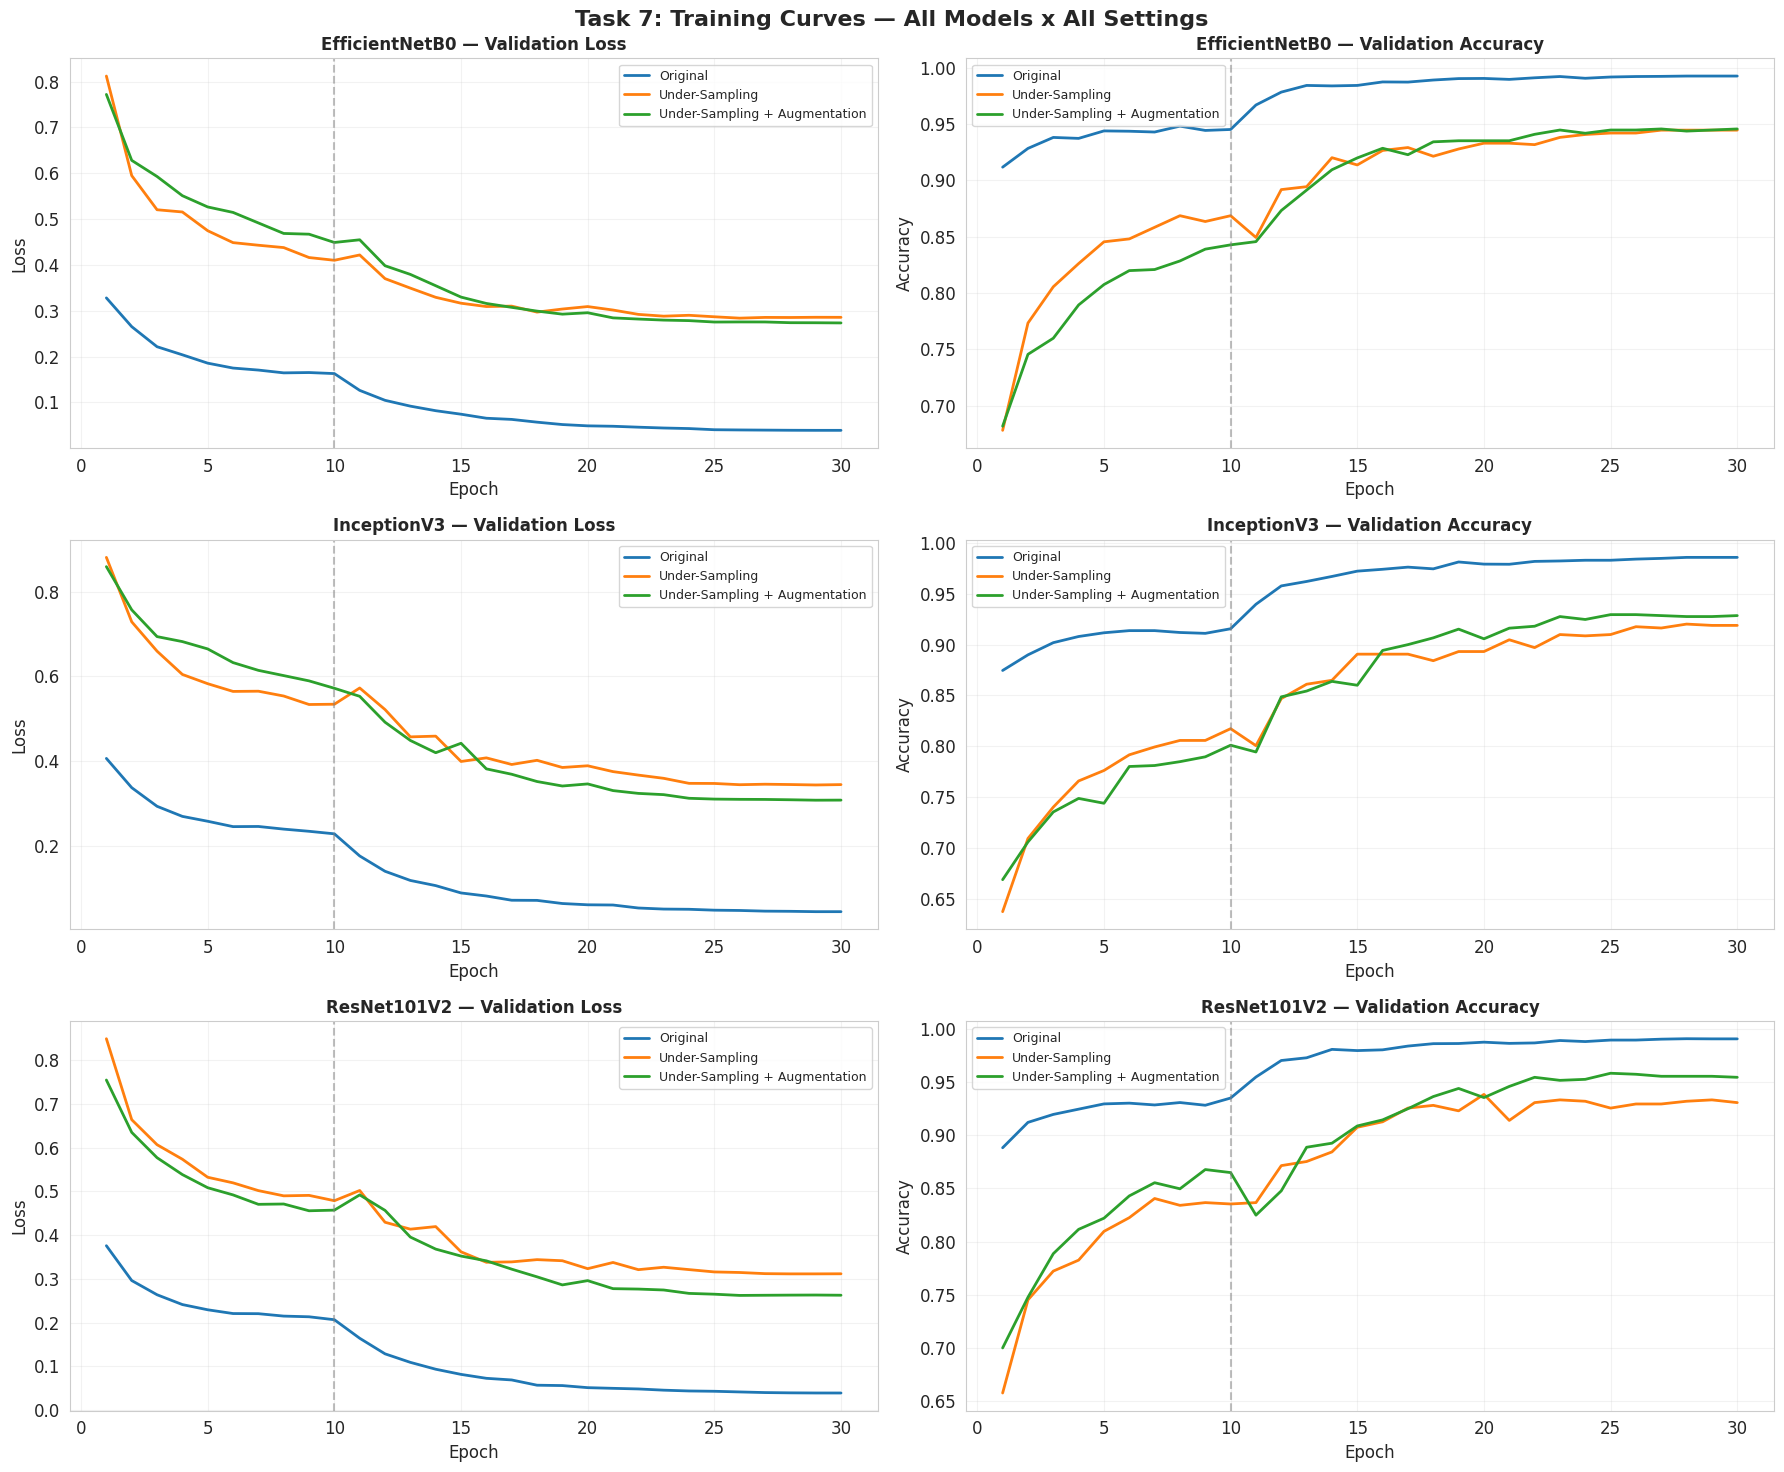

In [17]:
# model_names_list and setting_names_list already defined in the load cell above
# Reuse them here — MODEL_FNS and dataset_configs are not defined in this notebook
model_colors = {'EfficientNetB0': '#e74c3c', 'InceptionV3': '#3498db', 'ResNet101V2': '#2ecc71'}

fig, axes = plt.subplots(len(model_names_list), 2, figsize=(18, 5 * len(model_names_list)))

for row, m_name in enumerate(model_names_list):
    for s_name in setting_names_list:
        key = f"{m_name} | {s_name}"
        if key not in all_results:
            continue
        h = all_results[key]['history']
        ep = range(1, len(h['loss']) + 1)
        s_short = s_name.split(': ')[1] if ': ' in s_name else s_name

        axes[row, 0].plot(ep, h['val_loss'], linewidth=2, label=s_short)
        axes[row, 1].plot(ep, h['val_accuracy'], linewidth=2, label=s_short)

    axes[row, 0].set_title(f'{m_name} — Validation Loss', fontsize=12, fontweight='bold')
    axes[row, 0].set_xlabel('Epoch')
    axes[row, 0].set_ylabel('Loss')
    axes[row, 0].legend(fontsize=9)
    axes[row, 0].grid(True, alpha=0.25)
    axes[row, 0].axvline(x=WARMUP_EPOCHS, color='gray', linestyle='--', alpha=0.5, label='Phase switch')

    axes[row, 1].set_title(f'{m_name} — Validation Accuracy', fontsize=12, fontweight='bold')
    axes[row, 1].set_xlabel('Epoch')
    axes[row, 1].set_ylabel('Accuracy')
    axes[row, 1].legend(fontsize=9)
    axes[row, 1].grid(True, alpha=0.25)
    axes[row, 1].axvline(x=WARMUP_EPOCHS, color='gray', linestyle='--', alpha=0.5)

fig.suptitle('Task 7: Training Curves — All Models x All Settings',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('task7_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Learning Rate vs Epoch

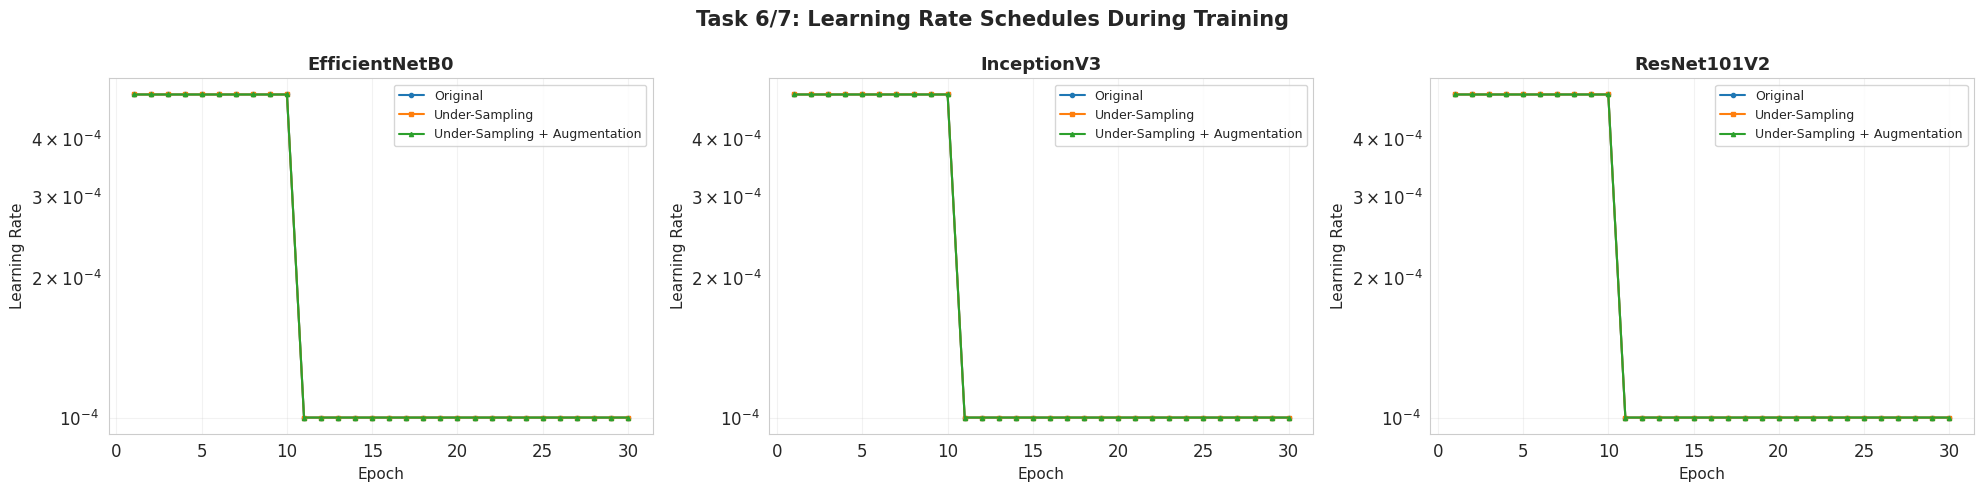

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
markers = ['o', 's', '^']

for ax, m_name in zip(axes, model_names_list):
    for i, s_name in enumerate(setting_names_list):
        key = f"{m_name} | {s_name}"
        if key not in all_results:
            continue
        h = all_results[key]['history']
        n_epochs = len(h['loss'])
        # Key is 'learning_rate' in Keras; fall back to synthetic schedule if absent
        lr_vals = h.get('learning_rate',
                        [WARMUP_LR] * min(WARMUP_EPOCHS, n_epochs) +
                        [FINETUNE_LR] * max(0, n_epochs - WARMUP_EPOCHS))
        s_short = s_name.split(': ')[1] if ': ' in s_name else s_name
        ax.plot(range(1, len(lr_vals) + 1), lr_vals, '-', marker=markers[i],
                markersize=3, linewidth=1.5, label=s_short)

    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Learning Rate', fontsize=11)
    ax.set_title(f'{m_name}', fontsize=13, fontweight='bold')
    ax.set_yscale('log')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)

fig.suptitle('Task 6/7: Learning Rate Schedules During Training',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('task6_lr_vs_epoch.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Confusion Matrices

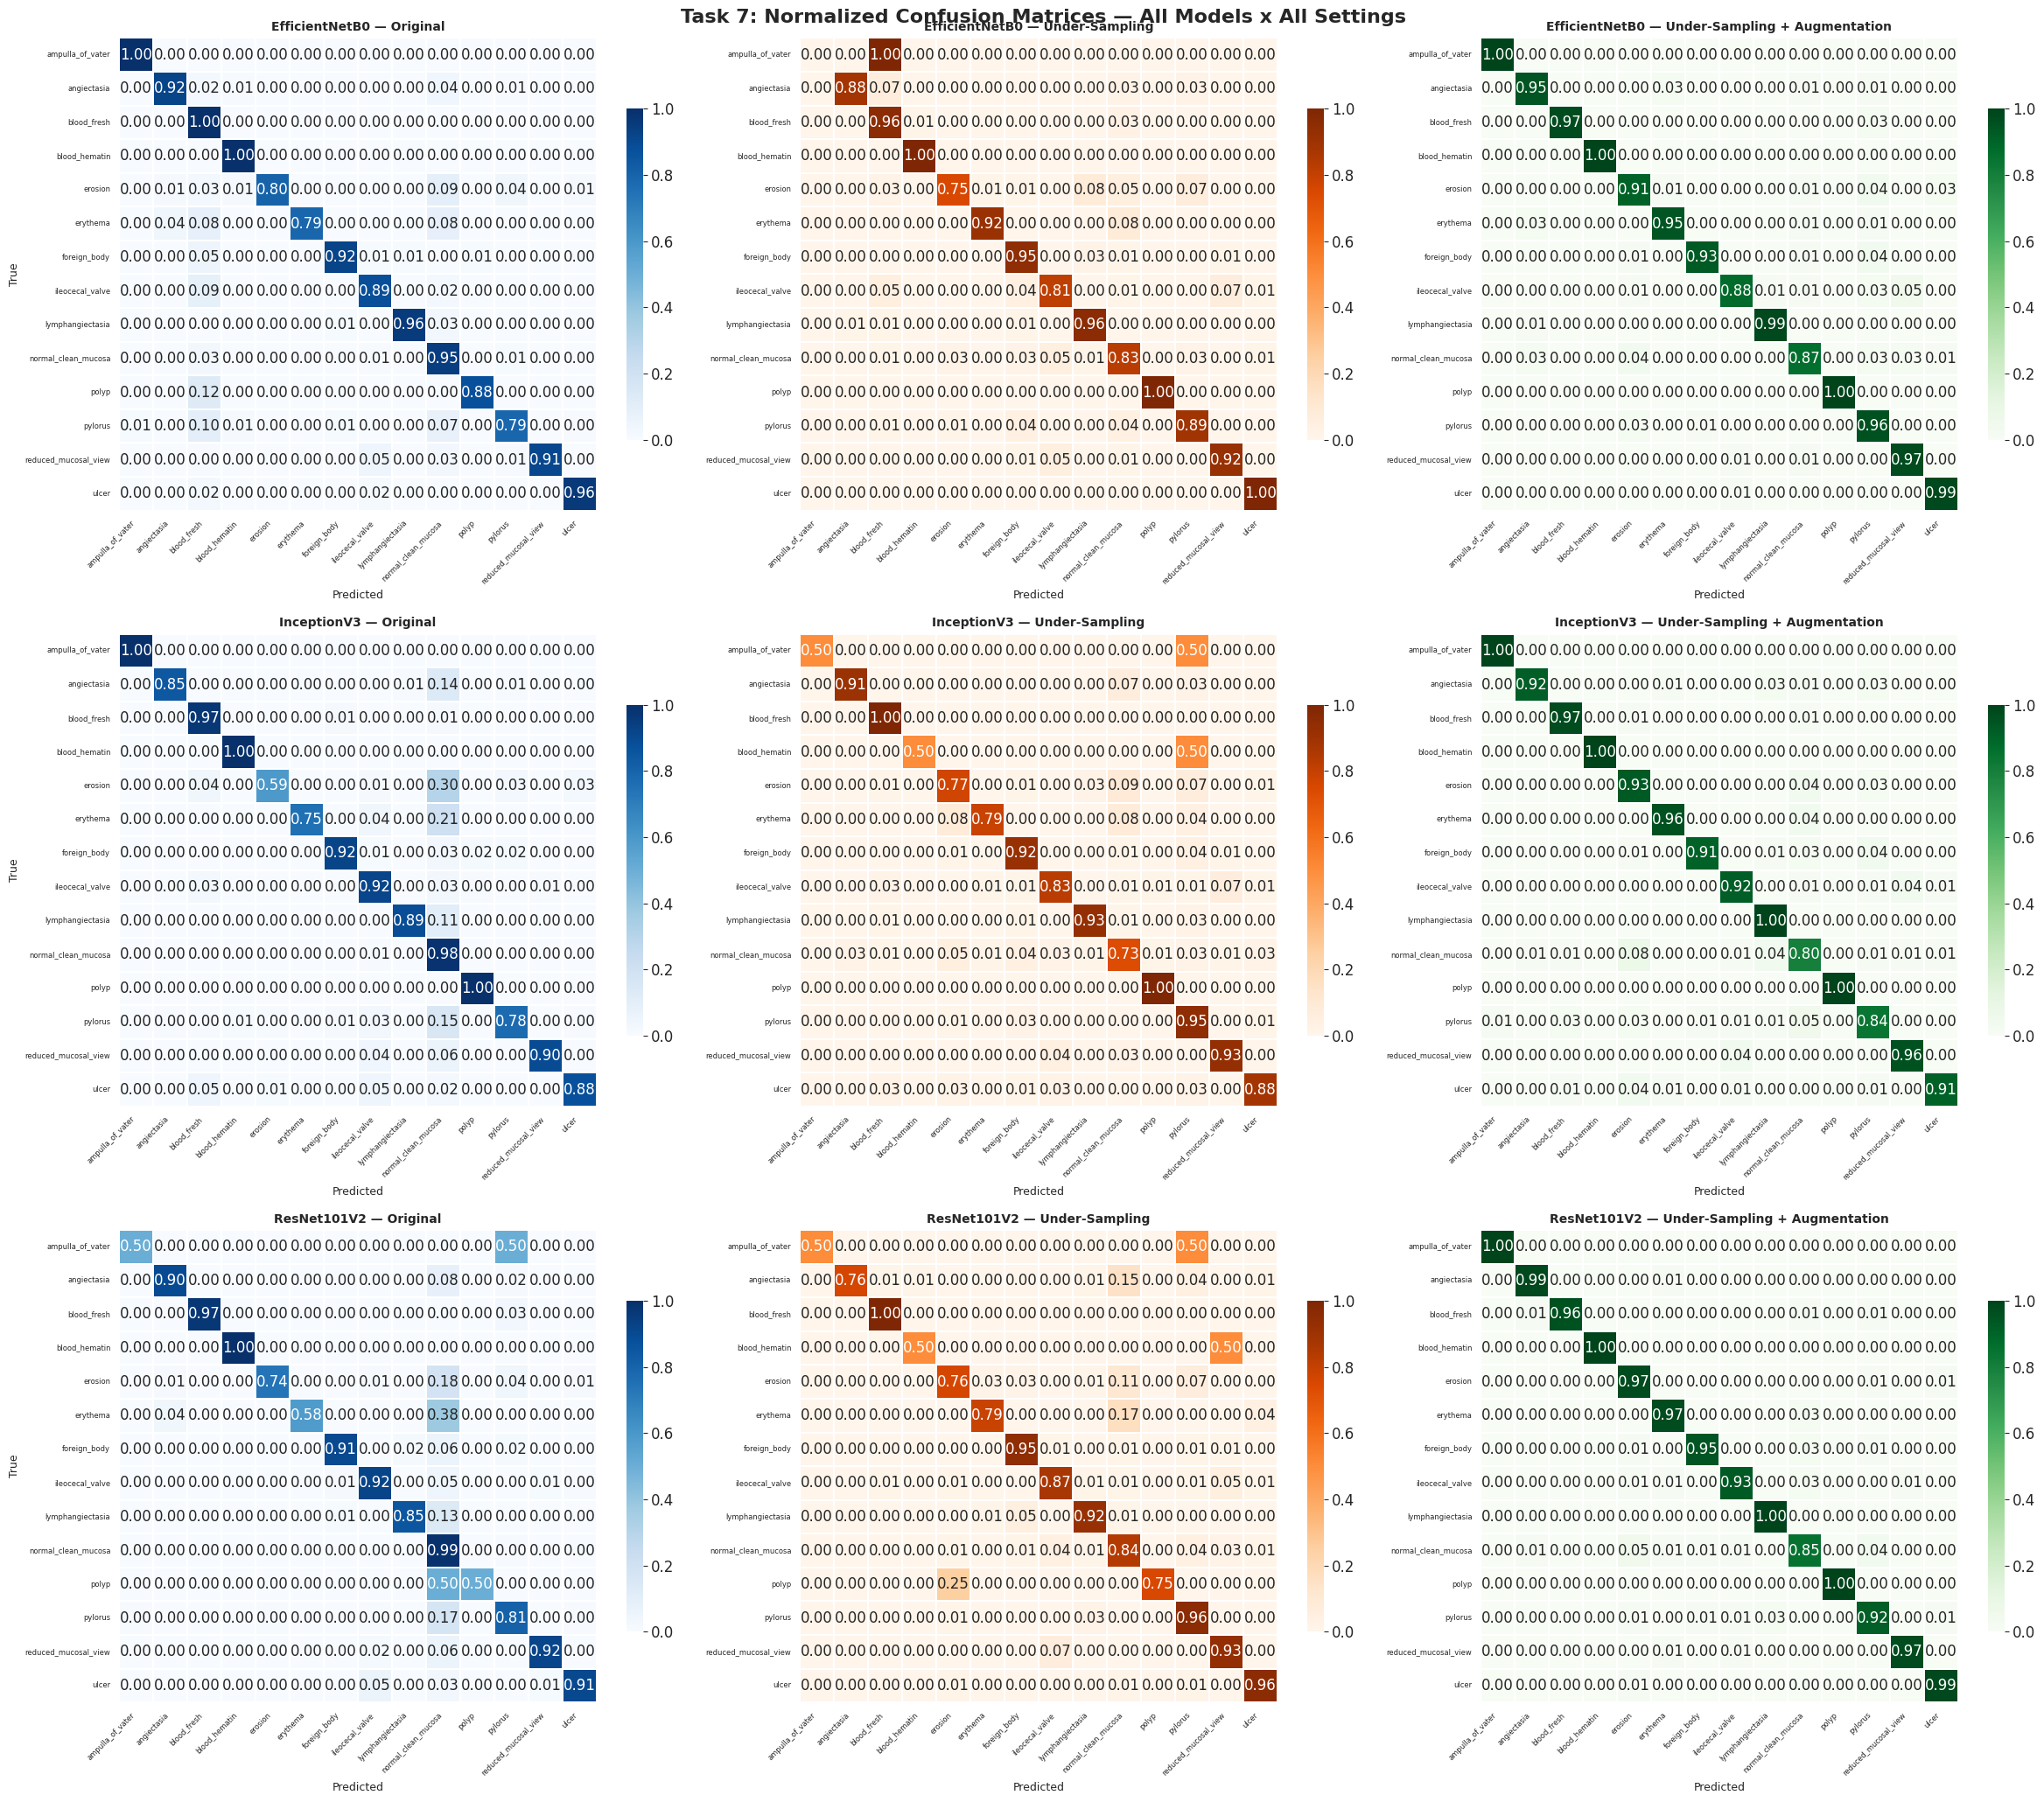

In [19]:
n_models = len(model_names_list)
n_settings = len(setting_names_list)
cmaps = ['Blues', 'Oranges', 'Greens']

fig, axes = plt.subplots(n_models, n_settings,
                         figsize=(8 * n_settings, 7 * n_models))

for row, m_name in enumerate(model_names_list):
    for col, s_name in enumerate(setting_names_list):
        key = f"{m_name} | {s_name}"
        if key not in all_results:
            axes[row, col].set_visible(False)
            continue
        result = all_results[key]
        cm = confusion_matrix(result['y_true'], result['y_pred'])
        cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

        sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap=cmaps[col], ax=axes[row, col],
                    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                    cbar_kws={'shrink': 0.7}, linewidths=0.3, vmin=0, vmax=1)
        s_short = s_name.split(': ')[1] if ': ' in s_name else s_name
        axes[row, col].set_title(f'{m_name} — {s_short}', fontsize=10, fontweight='bold')
        axes[row, col].set_xlabel('Predicted', fontsize=9)
        axes[row, col].set_ylabel('True' if col == 0 else '', fontsize=9)
        for lbl in axes[row, col].get_xticklabels():
            lbl.set_fontsize(6)
            lbl.set_ha('right')
            lbl.set_rotation(45)
        for lbl in axes[row, col].get_yticklabels():
            lbl.set_fontsize(6)

fig.suptitle('Task 7: Normalized Confusion Matrices — All Models x All Settings',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('task7_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Comparison Table

Task 7: Full Comparison — All Models x All Settings
         Model                                  Setting  Accuracy  Precision  Recall  F1-Score
EfficientNetB0                      Setting 1: Original    0.9320     0.9627  0.9320    0.9442
EfficientNetB0                Setting 2: Under-Sampling    0.8933     0.8954  0.8933    0.8917
EfficientNetB0 Setting 3: Under-Sampling + Augmentation    0.9543     0.9558  0.9543    0.9544
   InceptionV3                      Setting 1: Original    0.9550     0.9580  0.9550    0.9550
   InceptionV3                Setting 2: Under-Sampling    0.8805     0.8836  0.8805    0.8798
   InceptionV3 Setting 3: Under-Sampling + Augmentation    0.9371     0.9385  0.9371    0.9372
   ResNet101V2                      Setting 1: Original    0.9639     0.9635  0.9639    0.9631
   ResNet101V2                Setting 2: Under-Sampling    0.8869     0.8942  0.8869    0.8868
   ResNet101V2 Setting 3: Under-Sampling + Augmentation    0.9648     0.9650  0.9648    0.964

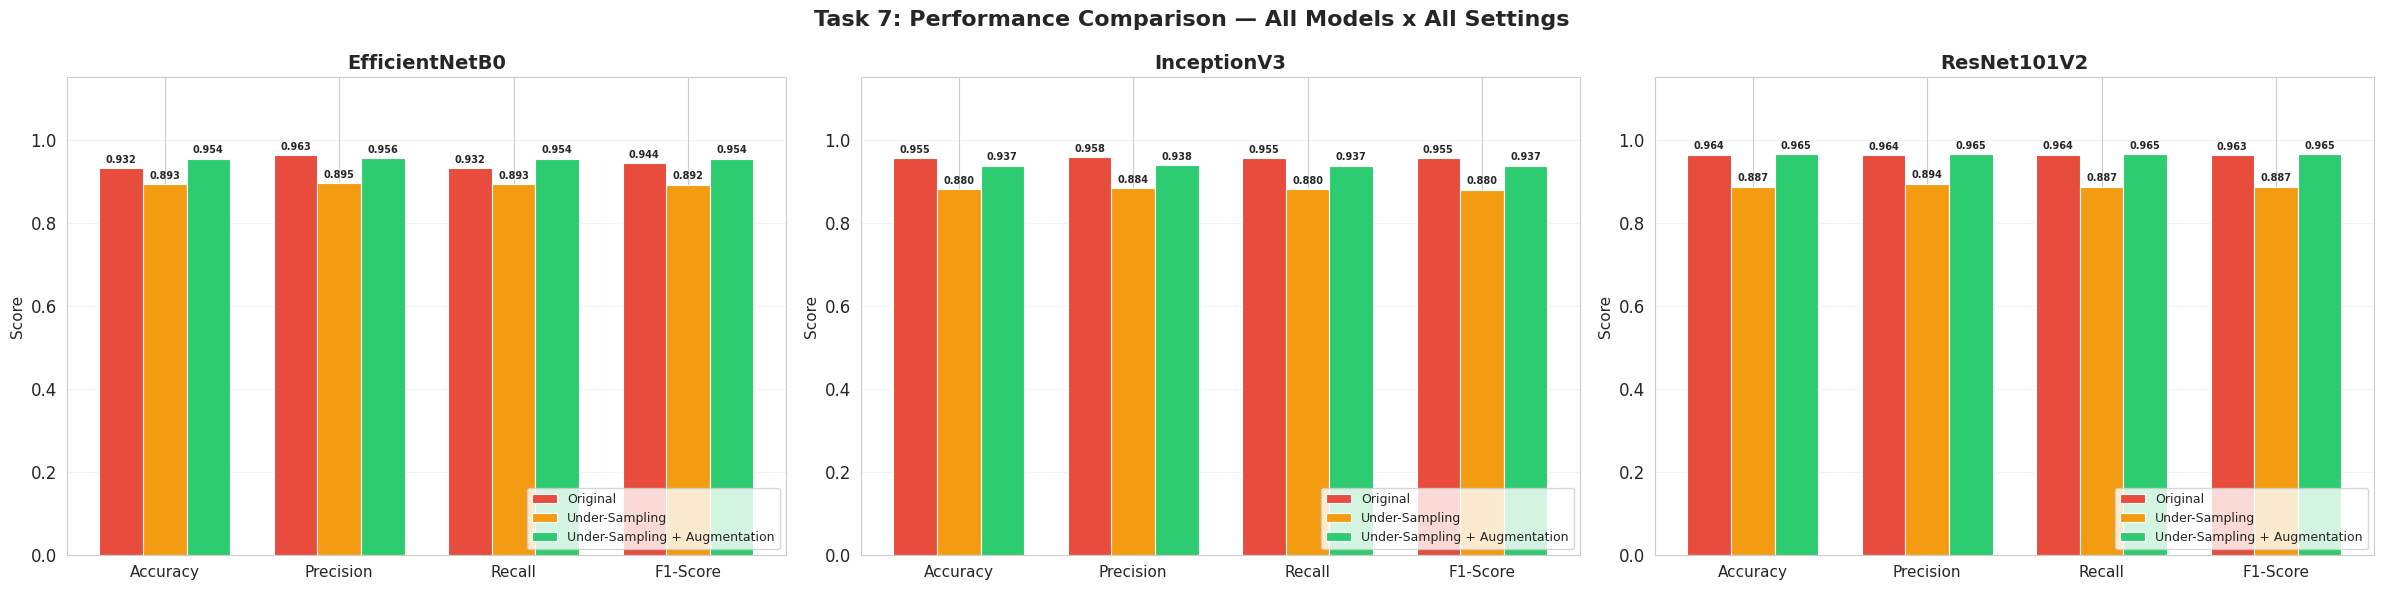

In [20]:
rows = []
for key, result in all_results.items():
    parts = key.split(' | ')
    m_name = parts[0]
    s_name = parts[1] if len(parts) > 1 else key
    rows.append({
        'Model': m_name,
        'Setting': s_name,
        'Accuracy': result['metrics']['Accuracy'],
        'Precision': result['metrics']['Precision'],
        'Recall': result['metrics']['Recall'],
        'F1-Score': result['metrics']['F1-Score'],
    })
comparison_df = pd.DataFrame(rows)

print("Task 7: Full Comparison — All Models x All Settings")
print("=" * 100)
print(comparison_df.to_string(index=False, float_format='%.4f'))
print("=" * 100)

metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
setting_colors = {'Setting 1: Original': '#e74c3c',
                  'Setting 2: Under-Sampling': '#f39c12',
                  'Setting 3: Under-Sampling + Augmentation': '#2ecc71'}

fig, axes = plt.subplots(1, len(model_names_list), figsize=(8 * len(model_names_list), 6))
if len(model_names_list) == 1:
    axes = [axes]

for ax, m_name in zip(axes, model_names_list):
    sub = comparison_df[comparison_df['Model'] == m_name]
    x = np.arange(len(metrics_list))
    width = 0.25
    for i, (_, row) in enumerate(sub.iterrows()):
        vals = [row[m] for m in metrics_list]
        color = list(setting_colors.values())[i % len(setting_colors)]
        s_short = row['Setting'].split(': ')[1] if ': ' in row['Setting'] else row['Setting']
        bars = ax.bar(x + i * width, vals, width, label=s_short,
                      color=color, edgecolor='white', linewidth=0.8)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')
    ax.set_xticks(x + width)
    ax.set_xticklabels(metrics_list, fontsize=11)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title(m_name, fontsize=14, fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(axis='y', alpha=0.25)

fig.suptitle('Task 7: Performance Comparison — All Models x All Settings',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('task7_comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Classification Reports

In [21]:
for key, result in all_results.items():
    print(f"\n{'='*70}")
    print(f"Classification Report: {key}")
    print(f"{'='*70}")
    print(classification_report(result['y_true'], result['y_pred'],
                                target_names=CLASS_NAMES, zero_division=0))


Classification Report: EfficientNetB0 | Setting 1: Original
                      precision    recall  f1-score   support

    ampulla_of_vater       0.33      1.00      0.50         2
         angiectasia       0.96      0.92      0.94       130
         blood_fresh       0.20      1.00      0.33        67
       blood_hematin       0.17      1.00      0.29         1
             erosion       0.95      0.80      0.87        76
            erythema       0.95      0.79      0.86        24
        foreign_body       0.95      0.92      0.93       116
     ileocecal_valve       0.91      0.89      0.90       629
    lymphangiectasia       0.90      0.96      0.93        89
 normal_clean_mucosa       0.99      0.95      0.97      5151
               polyp       0.78      0.88      0.82         8
             pylorus       0.75      0.79      0.77       229
reduced_mucosal_view       0.99      0.91      0.95       436
               ulcer       0.97      0.96      0.96       128

       

---
## Performance Heatmap

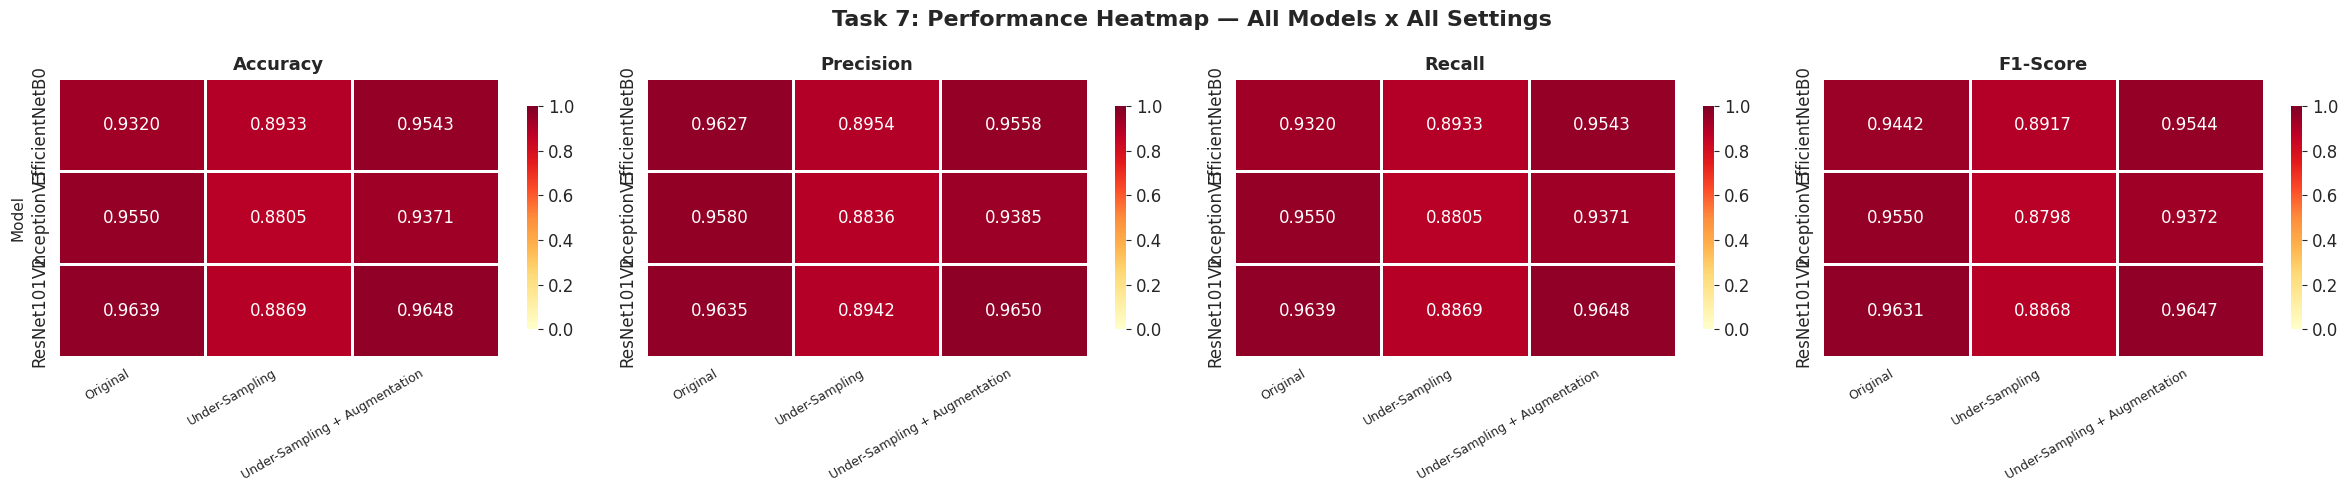


Best overall configuration: ResNet101V2 | Setting 3: Under-Sampling + Augmentation
  F1-Score: 0.9647
  Accuracy: 0.9648


In [22]:
metrics_pivot = comparison_df.pivot_table(
    index='Model', columns='Setting', values='F1-Score')
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
for i, metric in enumerate(metrics_list):
    pivot = comparison_df.pivot_table(index='Model', columns='Setting', values=metric)
    pivot.columns = [c.split(': ')[1] if ': ' in c else c for c in pivot.columns]
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd', ax=axes[i],
                linewidths=1, linecolor='white', vmin=0, vmax=1,
                cbar_kws={'shrink': 0.8})
    axes[i].set_title(metric, fontsize=13, fontweight='bold')
    axes[i].set_ylabel('' if i > 0 else 'Model', fontsize=11)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    for lbl in axes[i].get_xticklabels():
        lbl.set_fontsize(9)
        lbl.set_ha('right')

fig.suptitle('Task 7: Performance Heatmap — All Models x All Settings',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('task7_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

best_key = max(all_results, key=lambda k: all_results[k]['metrics']['F1-Score'])
best_r = all_results[best_key]
print(f"\nBest overall configuration: {best_key}")
print(f"  F1-Score: {best_r['metrics']['F1-Score']:.4f}")
print(f"  Accuracy: {best_r['metrics']['Accuracy']:.4f}")